In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

drive_file_path = '/content/drive/MyDrive/bank_transactions_data_2.csv'

df = pd.read_csv(drive_file_path)
print("Dataset loaded successfully.")

Dataset loaded successfully.


In [19]:
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39


In [20]:
df.shape

(2512, 16)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   object 
 1   AccountID                2512 non-null   object 
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   object 
 4   TransactionType          2512 non-null   object 
 5   Location                 2512 non-null   object 
 6   DeviceID                 2512 non-null   object 
 7   IP Address               2512 non-null   object 
 8   MerchantID               2512 non-null   object 
 9   Channel                  2512 non-null   object 
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   object 
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  AccountBalance          

# Exploratory data analysis (EDA)

In [22]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100 #percentage
print("Missing values in each column:")
print(pd.concat([missing, missing_pct.round(2)], axis=1, keys=["count", "%"])) #will join both the dataframes

Missing values in each column:
                         count    %
TransactionID                0  0.0
AccountID                    0  0.0
TransactionAmount            0  0.0
TransactionDate              0  0.0
TransactionType              0  0.0
Location                     0  0.0
DeviceID                     0  0.0
IP Address                   0  0.0
MerchantID                   0  0.0
Channel                      0  0.0
CustomerAge                  0  0.0
CustomerOccupation           0  0.0
TransactionDuration          0  0.0
LoginAttempts                0  0.0
AccountBalance               0  0.0
PreviousTransactionDate      0  0.0


In [23]:
# Numeric
print(df.describe())

       TransactionAmount  CustomerAge  TransactionDuration  LoginAttempts  \
count        2512.000000  2512.000000          2512.000000    2512.000000   
mean          297.593778    44.673965           119.643312       1.124602   
std           291.946243    17.792198            69.963757       0.602662   
min             0.260000    18.000000            10.000000       1.000000   
25%            81.885000    27.000000            63.000000       1.000000   
50%           211.140000    45.000000           112.500000       1.000000   
75%           414.527500    59.000000           161.000000       1.000000   
max          1919.110000    80.000000           300.000000       5.000000   

       AccountBalance  
count     2512.000000  
mean      5114.302966  
std       3900.942499  
min        101.250000  
25%       1504.370000  
50%       4735.510000  
75%       7678.820000  
max      14977.990000  


In [24]:
# This filters the dataframe to only rows where LoginAttempts > 1
suspicious = df[df["LoginAttempts"] > 1]
print("Transactions with LoginAttempts > 1:", suspicious.shape[0])

# And as a percentage of all transactions
print("That's", round(suspicious.shape[0] / len(df) * 100, 2), "% of all transactions")

Transactions with LoginAttempts > 1: 122
That's 4.86 % of all transactions


In [25]:
# IQR for TransactionAmount
Q1 = df["TransactionAmount"].quantile(0.25)
Q3 = df["TransactionAmount"].quantile(0.75)
IQR = Q3 - Q1

# Calculate bounds
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

suspicious = df[df["TransactionAmount"]> upper ]
print("That's", round(suspicious.shape[0] / len(df) * 100, 2), "% of all transactions")

That's 4.5 % of all transactions


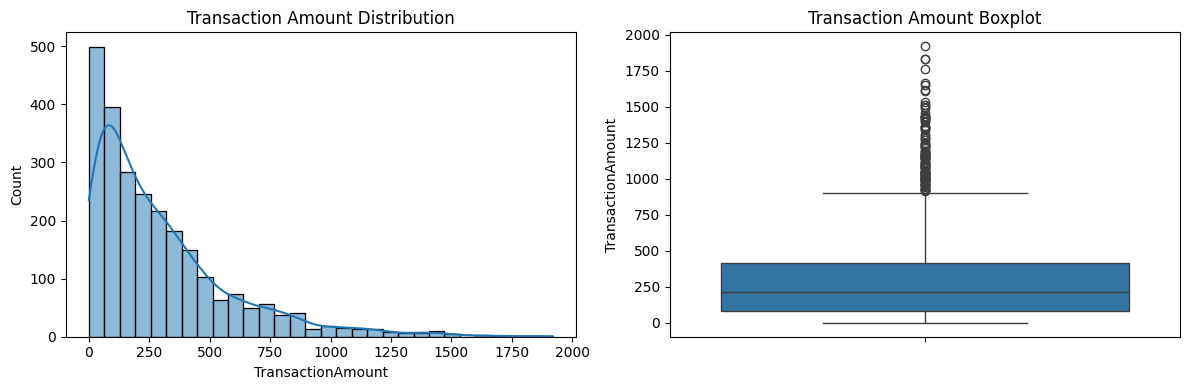

In [26]:
#visualization for transacation amount
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram with KDE curve
sns.histplot(df["TransactionAmount"], kde=True, bins=30, ax=axes[0])
axes[0].set_title("Transaction Amount Distribution")

# Boxplot
sns.boxplot(df["TransactionAmount"], ax=axes[1])
axes[1].set_title("Transaction Amount Boxplot")

plt.tight_layout()
plt.show()

In [27]:
#Comparing trancsaction amount with login attemps
suspicious = df[(df["TransactionAmount"] > upper) & (df["LoginAttempts"] > 1)]
print("That's", round(suspicious.shape[0] / len(df) * 100, 2), "% of transactions")

That's 0.2 % of transactions


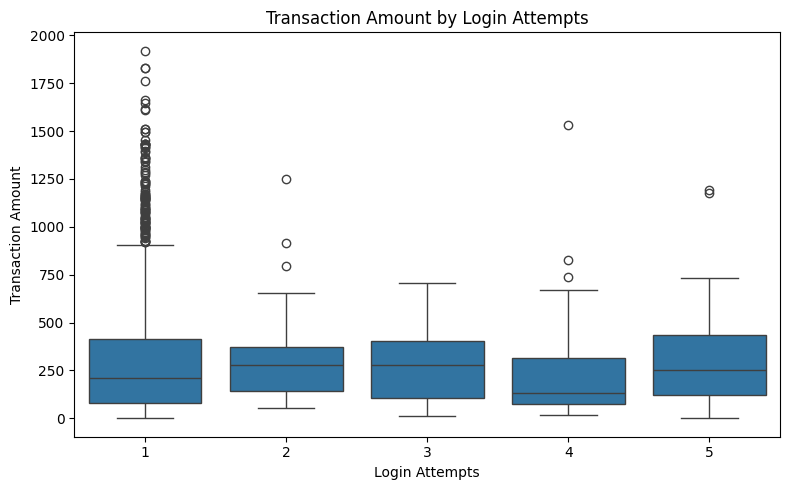

In [28]:
#visualizing transaction amount relationship with login attempts
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(data=df, x="LoginAttempts", y="TransactionAmount", ax=ax)

ax.set_title("Transaction Amount by Login Attempts")
ax.set_xlabel("Login Attempts")
ax.set_ylabel("Transaction Amount")

plt.tight_layout()
plt.show()

LoginAttempts and Transaction Amount are largely independent signals. High login attemps don't tend to come with high amounts, and high amounts mostly happen on first login attempts. This indicates that two independent signals catch different kinds of suspicious behavior.

In [29]:
# Check IQR for transaction and account balance
for col in ["TransactionAmount", "AccountBalance"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    lower = Q1 - 1.5 * IQR

    suspicious = df[df[col] > upper]
    print(f"{col}:")
    print(f"  Upper bound: {upper:.2f}")
    print(f"  Outliers: {len(suspicious)} ({round(len(suspicious)/len(df)*100,2)}%)")
    print()

TransactionAmount:
  Upper bound: 913.49
  Outliers: 113 (4.5%)

AccountBalance:
  Upper bound: 16940.49
  Outliers: 0 (0.0%)



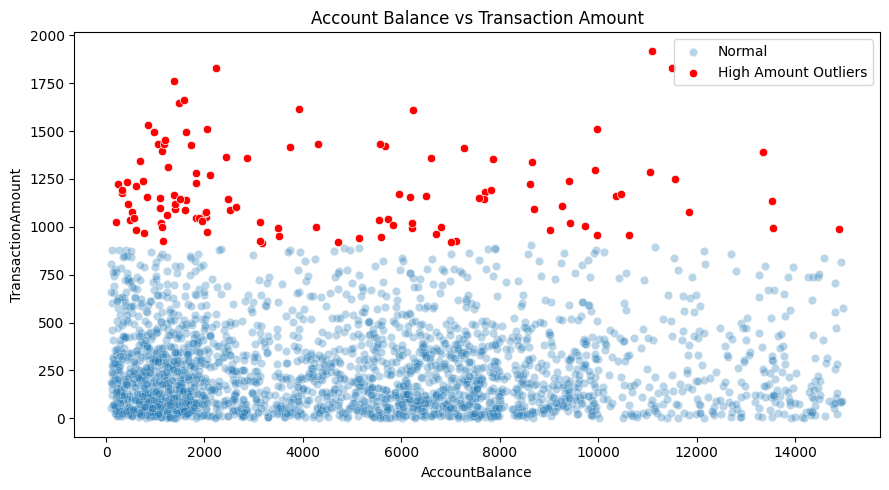

In [30]:
#visualizing relationship of account balance and transaction amount
fig, ax = plt.subplots(figsize=(9, 5))

# transactions in blue
sns.scatterplot(data=df, x="AccountBalance", y="TransactionAmount",
                alpha=0.3, ax=ax, label="Normal")

# suspicious high amount transactions in red
suspicious = df[df["TransactionAmount"] > 913.49]
sns.scatterplot(data=suspicious, x="AccountBalance", y="TransactionAmount",
                color="red", ax=ax, label="High Amount Outliers")

ax.set_title("Account Balance vs Transaction Amount")
plt.tight_layout()
plt.show()

Raw account balance alone doesn't predict suspicious transactions but the ratio of transaction amount ot account balance might

In [31]:
# Check IQR for transaction amount and customer occupation
for occupation in df["CustomerOccupation"].unique():
    subset = df[df["CustomerOccupation"] == occupation]["TransactionAmount"]

    Q1 = subset.quantile(0.25)
    Q3 = subset.quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR

    suspicious = subset[subset > upper]
    print(f"Occupation: {occupation}")
    print(f"  Upper bound: {upper:.2f}")
    print(f"  Outliers: {len(suspicious)} ({round(len(suspicious)/len(subset)*100,2)}%)")
    print()

Occupation: Doctor
  Upper bound: 920.46
  Outliers: 27 (4.28%)

Occupation: Student
  Upper bound: 939.97
  Outliers: 31 (4.72%)

Occupation: Retired
  Upper bound: 851.26
  Outliers: 34 (5.68%)

Occupation: Engineer
  Upper bound: 877.30
  Outliers: 31 (4.96%)



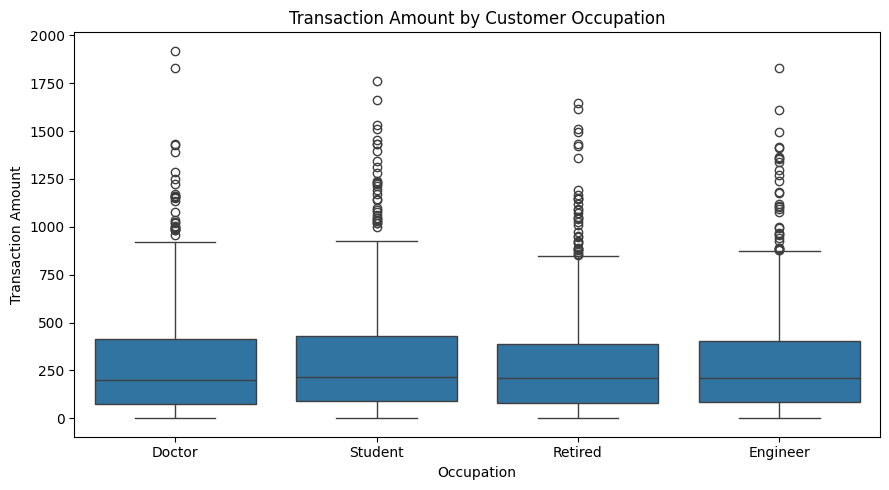

In [32]:
#visualizing transaction amount with customer occupation
fig, ax = plt.subplots(figsize=(9, 5))

sns.boxplot(data=df, x="CustomerOccupation", y="TransactionAmount", ax=ax)

ax.set_title("Transaction Amount by Customer Occupation")
ax.set_xlabel("Occupation")
ax.set_ylabel("Transaction Amount")

plt.tight_layout()
plt.show()

The dataset contains 2,512 bank transactions across 16 columns with no missing values or duplicates. Two key anomaly signals were identified: 4.86% of transactions had more than one login attempt, and 4.5% had unusually high transaction amounts above $914 (IQR method). These signals are largely independent, with only 0.2% of transactions flagging both suggesting they capture different types of suspicious behavior.

Visualizations confirmed a right-skewed distribution in TransactionAmount, with most transactions clustering below $500. While AccountBalance showed no outliers alone, high-value transactions were spread across all balance levels, suggesting the ratio between the two is more meaningful than either individually. Columns like TransactionDuration, Channel, and CustomerOccupation showed no strong standalone patterns and were ruled out as primary signals. These findings will directly inform Feature Engineering, where ratio-based and time-based features will be created to better capture anomalous behavior. bold text


# Feature engineering

In [34]:
# Days since previous transaction
df["TimeSincePreviousTransaction"] = (
    df["TransactionDate"] - df["PreviousTransactionDate"]
).dt.days.abs()

# Ratio of transaction amount to account balance
df["AmountToBalanceRatio"] = df["TransactionAmount"] / df["AccountBalance"]

# Binary flag for suspicious login attempts
df["HighLoginFlag"] = (df["LoginAttempts"] > 1).astype(int)

# Binary flag for high transaction amounts
df["HighAmountFlag"] = (df["TransactionAmount"] > 914).astype(int)

# new features
print(df[["TransactionAmount", "AccountBalance", "AmountToBalanceRatio",
          "TimeSincePreviousTransaction", "HighLoginFlag", "HighAmountFlag"]].head(10))

   TransactionAmount  AccountBalance  AmountToBalanceRatio  \
0              14.09         5112.21              0.002756   
1             376.24        13758.91              0.027345   
2             126.29         1122.35              0.112523   
3             184.50         8569.06              0.021531   
4              13.45         7429.40              0.001810   
5              92.15          781.68              0.117887   
6               7.08        13316.71              0.000532   
7             171.42         2796.24              0.061304   
8             106.23         9095.14              0.011680   
9             815.96         1021.88              0.798489   

   TimeSincePreviousTransaction  HighLoginFlag  HighAmountFlag  
0                           573              0               0  
1                           496              0               0  
2                           483              0               0  
3                           549              0           

In [37]:
# Z-score = how many standard deviations away from the mean for that account

df["AmountZScore"] = df.groupby("AccountID")["TransactionAmount"].transform(
    lambda x: (x - x.mean()) / x.std()
)

df["AmountZScore"] = df["AmountZScore"].fillna(0)

# Checking for suspicious ones
print(df[["AccountID", "TransactionAmount", "AmountZScore"]].sort_values(
    "AmountZScore", ascending=False).head(10))

     AccountID  TransactionAmount  AmountZScore
2059   AC00267             796.30      2.669343
176    AC00363            1362.55      2.558117
755    AC00460            1607.55      2.468863
2079   AC00054             738.94      2.441117
1972   AC00480            1087.90      2.440092
934    AC00456            1022.75      2.408272
2129   AC00304            1154.79      2.391722
218    AC00070             890.24      2.375930
719    AC00465             737.34      2.366490
60     AC00438             568.52      2.359699


In [35]:
# categorical variables
df_encoded = pd.get_dummies(df, columns=["TransactionType", "Channel", "CustomerOccupation"],
                             drop_first=True)

# Drop columns that aren't useful
cols_to_drop = ["TransactionID", "AccountID", "DeviceID", "IP Address",
                "MerchantID", "Location", "TransactionDate", "PreviousTransactionDate"]

df_encoded = df_encoded.drop(columns=cols_to_drop)

print("Final shape:", df_encoded.shape)
print("\nColumns:", df_encoded.columns.tolist())

Final shape: (2512, 15)

Columns: ['TransactionAmount', 'CustomerAge', 'TransactionDuration', 'LoginAttempts', 'AccountBalance', 'TimeSincePreviousTransaction', 'AmountToBalanceRatio', 'HighLoginFlag', 'HighAmountFlag', 'TransactionType_Debit', 'Channel_Branch', 'Channel_Online', 'CustomerOccupation_Engineer', 'CustomerOccupation_Retired', 'CustomerOccupation_Student']


In [38]:
# Adding AmountZScore to df_encoded before we scale
df_encoded["AmountZScore"] = df["AmountZScore"].values

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_encoded)
df_scaled = pd.DataFrame(df_scaled, columns=df_encoded.columns)

print("Final shape:", df_encoded.shape)
print("Columns:", df_encoded.columns.tolist())

Final shape: (2512, 16)
Columns: ['TransactionAmount', 'CustomerAge', 'TransactionDuration', 'LoginAttempts', 'AccountBalance', 'TimeSincePreviousTransaction', 'AmountToBalanceRatio', 'HighLoginFlag', 'HighAmountFlag', 'TransactionType_Debit', 'Channel_Branch', 'Channel_Online', 'CustomerOccupation_Engineer', 'CustomerOccupation_Retired', 'CustomerOccupation_Student', 'AmountZScore']


# Dimensionality Reduction Visualization

Variance explained by PC1: 0.169
Variance explained by PC2: 0.14
Total variance retained: 0.309


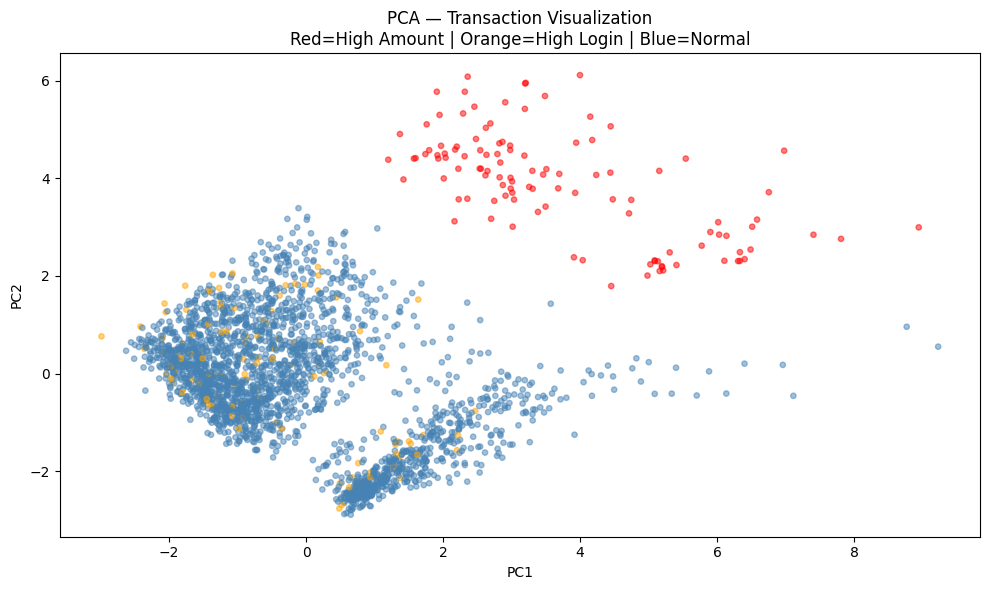

In [39]:
from sklearn.decomposition import PCA

# PCA compresses your columns
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_scaled)

# how much of the original information is retained
print("Variance explained by PC1:", round(pca.explained_variance_ratio_[0], 3))
print("Variance explained by PC2:", round(pca.explained_variance_ratio_[1], 3))
print("Total variance retained:", round(pca.explained_variance_ratio_.sum(), 3))

pca_df = pd.DataFrame(pca_result, columns=["PC1", "PC2"])
pca_df["HighAmountFlag"] = df_encoded["HighAmountFlag"].values
pca_df["HighLoginFlag"] = df_encoded["HighLoginFlag"].values

fig, ax = plt.subplots(figsize=(10, 6))
colors = pca_df.apply(lambda r: "red" if r["HighAmountFlag"] == 1
                      else "orange" if r["HighLoginFlag"] == 1
                      else "steelblue", axis=1)
ax.scatter(pca_df["PC1"], pca_df["PC2"], c=colors, alpha=0.5, s=15)
ax.set_title("PCA — Transaction Visualization\nRed=High Amount | Orange=High Login | Blue=Normal")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.tight_layout()
plt.show()

The PCA visualization retained 30.9% of the total variance across two components. Despite this modest retention, the plot revealed a clear separation between high-amount transactions (red) and normal transactions (blue), with red dots clustering distinctly in the upper right of the plot. High-login transactions (orange) remained mixed within the normal blue cluster, suggesting that multiple login attempts alone do not separate suspicious behavior in linear space.

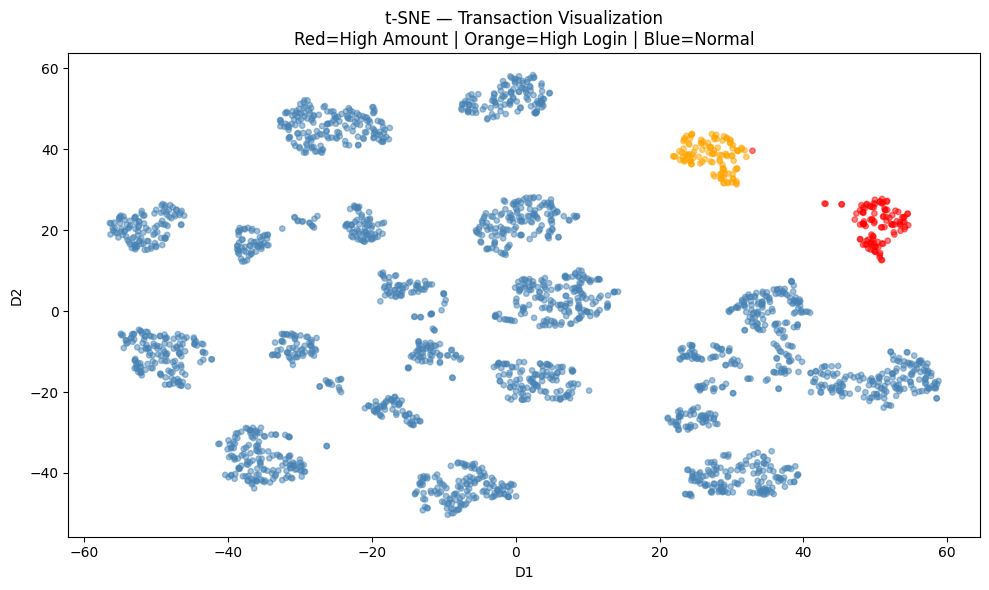

In [40]:
from sklearn.manifold import TSNE

# It tries to keep similar transactions close together and will push different ones apart
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_result = tsne.fit_transform(df_scaled)

tsne_df = pd.DataFrame(tsne_result, columns=["D1", "D2"])
tsne_df["HighAmountFlag"] = df_encoded["HighAmountFlag"].values
tsne_df["HighLoginFlag"] = df_encoded["HighLoginFlag"].values

fig, ax = plt.subplots(figsize=(10, 6))
colors = tsne_df.apply(lambda r: "red" if r["HighAmountFlag"] == 1
                       else "orange" if r["HighLoginFlag"] == 1
                       else "steelblue", axis=1)
ax.scatter(tsne_df["D1"], tsne_df["D2"], c=colors, alpha=0.5, s=15)
ax.set_title("t-SNE — Transaction Visualization\nRed=High Amount | Orange=High Login | Blue=Normal")
ax.set_xlabel("D1")
ax.set_ylabel("D2")
plt.tight_layout()
plt.show()


The t-SNE visualization provided a cleaner and more detailed picture. Both high-amount (red) and high-login (orange) transactions formed their own distinct isolated clusters, completely separate from the normal transactions. The normal blue transactions split into multiple sub-clusters, likely reflecting natural groupings by occupation or channel. This separation confirms that the engineered features carry meaningful signal for distinguishing anomalous transactions, giving confidence that the unsupervised models in the next step will effectively identify suspicious behavior.


# Anomaly Detection

In [43]:
from sklearn.cluster import KMeans

# n_clusters = 8 groups transactions into 8 natural clusters
kmeans = KMeans(n_clusters=8, random_state=42)
df_encoded["KMeans_Cluster"] = kmeans.fit_predict(df_scaled)

# transaction's distance to its cluster center
centers = kmeans.cluster_centers_
df_encoded["KMeans_Distance"] = np.array([
    np.linalg.norm(df_scaled.iloc[i] - centers[df_encoded["KMeans_Cluster"].iloc[i]])
    for i in range(len(df_scaled))
])

# 5% furthest transactions as anomalies
threshold_kmeans = df_encoded["KMeans_Distance"].quantile(0.95)
df_encoded["KMeans_Anomaly"] = (df_encoded["KMeans_Distance"] > threshold_kmeans).astype(int)

print("K-Means anomalies:", df_encoded["KMeans_Anomaly"].sum())
print(df_encoded["KMeans_Distance"].describe())

K-Means anomalies: 126
count    2512.000000
mean        2.695660
std         0.847872
min         1.237790
25%         2.200080
50%         2.587231
75%         3.044468
max        14.266958
Name: KMeans_Distance, dtype: float64


In [48]:
# Try different numbers of clusters and see how many anomalies each finds

for n_clusters in [4, 6, 8, 10, 12]:
    km = KMeans(n_clusters=n_clusters, random_state=42)
    clusters = km.fit_predict(df_scaled)
    centers = km.cluster_centers_

    distances = np.array([
        np.linalg.norm(df_scaled.iloc[i] - centers[clusters[i]])
        for i in range(len(df_scaled))
    ])

    threshold = np.quantile(distances, 0.95)
    n_anomalies = (distances > threshold).sum()
    avg_distance = distances.mean().round(3)

    print(f"n_clusters={n_clusters}: anomalies={n_anomalies}, avg_distance={avg_distance}")

n_clusters=4: anomalies=126, avg_distance=3.252
n_clusters=6: anomalies=126, avg_distance=2.841
n_clusters=8: anomalies=126, avg_distance=2.696
n_clusters=10: anomalies=126, avg_distance=2.626
n_clusters=12: anomalies=126, avg_distance=2.533



K-Means clustering grouped the 2,512 transactions into natural clusters and flagged the 5% of transactions furthest from their cluster centers as anomalies. Parameter optimization was performed by testing n_clusters values of 4, 6, 8, 10, and 12. While the anomaly count remained stable at 126 across all values, average distance decreased as clusters increased, indicating tighter and more precise groupings. n_clusters=8 was selected as the optimal balance between cluster precision and avoiding overfitting to noise, producing a mean distance of 2.70 and identifying 126 anomalies.


In [45]:
from sklearn.neighbors import NearestNeighbors

#how far each transaction is from its 20 nearest neighbors
knn = NearestNeighbors(n_neighbors=20)
knn.fit(df_scaled)
distances, _ = knn.kneighbors(df_scaled)

# avg distance to all 20 neighbors
df_encoded["KNN_Distance"] = distances.mean(axis=1)

# 5% as anomalies
threshold_knn = df_encoded["KNN_Distance"].quantile(0.95)
df_encoded["KNN_Anomaly"] = (df_encoded["KNN_Distance"] > threshold_knn).astype(int)

print("KNN anomalies:", df_encoded["KNN_Anomaly"].sum())
print(df_encoded["KNN_Distance"].describe())

# how many were flagged by both
df_encoded["Both_Flags"] = ((df_encoded["KMeans_Anomaly"] == 1) &
                             (df_encoded["KNN_Anomaly"] == 1)).astype(int)
print("\nFlagged by both models:", df_encoded["Both_Flags"].sum())

KNN anomalies: 126
count    2512.000000
mean        1.722470
std         0.752611
min         0.594848
25%         1.258523
50%         1.523248
75%         1.940650
max         8.885077
Name: KNN_Distance, dtype: float64

Flagged by both models: 87


In [51]:
#different numbers of neighbors and see how it affects anomaly detection

for n_neighbors in [5, 10, 20, 30, 50]:
    knn = NearestNeighbors(n_neighbors=n_neighbors)
    knn.fit(df_scaled)
    distances, _ = knn.kneighbors(df_scaled)

    avg_distances = distances.mean(axis=1)
    threshold = np.quantile(avg_distances, 0.95)
    n_anomalies = (avg_distances > threshold).sum()

    print(f"n_neighbors={n_neighbors}: anomalies={n_anomalies}, avg_distance={avg_distances.mean().round(3)}")

n_neighbors=5: anomalies=126, avg_distance=1.06
n_neighbors=10: anomalies=126, avg_distance=1.394
n_neighbors=20: anomalies=126, avg_distance=1.722
n_neighbors=30: anomalies=126, avg_distance=1.926
n_neighbors=50: anomalies=126, avg_distance=2.2


The K-Nearest Neighbors algorithm measured the average distance of each transaction to its nearest neighbors, flagging isolated transactions as anomalies. Parameter optimization tested n_neighbors values of 5, 10, 20, 30, and 50. Smaller values captured more local patterns while larger values produced a smoother global view, with average distances rising from 1.06 to 2.20 across the range. n_neighbors=20 was selected as it balances local sensitivity with robustness to noise, identifying 126 anomalies with a mean neighbor distance of 1.72.

In [52]:
# combined inspection
df_encoded["TransactionAmount_orig"] = df["TransactionAmount"].values
df_encoded["AccountBalance_orig"] = df["AccountBalance"].values
df_encoded["LoginAttempts_orig"] = df["LoginAttempts"].values
df_encoded["CustomerOccupation_orig"] = df["CustomerOccupation"].values
df_encoded["Channel_orig"] = df["Channel"].values

# transactions flagged by both score highest
df_encoded["AnomalyScore"] = df_encoded["KMeans_Anomaly"] + df_encoded["KNN_Anomaly"]

# looking at 20 most suspicious transactions
top_anomalies = df_encoded[df_encoded["Both_Flags"] == 1].sort_values(
    "KMeans_Distance", ascending=False
)[["TransactionAmount_orig", "AccountBalance_orig",
   "LoginAttempts_orig", "CustomerOccupation_orig",
   "Channel_orig", "KMeans_Distance", "KNN_Distance"]].head(20)

print(top_anomalies.to_string())

      TransactionAmount_orig  AccountBalance_orig  LoginAttempts_orig CustomerOccupation_orig Channel_orig  KMeans_Distance  KNN_Distance
2273                  806.97               102.20                   1                 Student       Online        14.266958      8.206180
2191                  879.25               125.85                   1                 Student       Online        12.641164      6.989531
1459                  659.71               106.86                   1                 Student       Branch        11.032391      6.011157
274                  1176.28               323.69                   5                Engineer          ATM         9.969534      8.885077
934                  1022.75               207.74                   1                  Doctor       Branch         9.069055      6.659583
1258                  603.23               117.98                   1                 Student       Branch         8.984421      4.778481
2382                  761.73      

Cross-referencing both models revealed 87 transactions flagged by both K-Means and KNN simultaneously, representing the strongest anomaly candidates. Inspection of the top 20 most suspicious transactions revealed a dominant pattern. Students are making large transactions between 600 and 1,500 against account balances under 500, in some cases spending over 700% of their available balance in a single transaction. Additional red flags included transactions with 4-5 login attempts combined with high amounts. Notably, the same transaction amounts were less suspicious for Retired and Doctor customers with high balances, confirming that the ratio of transaction amount to account balance is the most powerful signal in detecting suspicious behavior.
